In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.regression.mixed_linear_model import MixedLM

# Configuración de plots
sns.set(font_scale=1.3, style="ticks")
plt.rcParams["figure.dpi"] = 100

print("Librerías OK ✓")

Librerías OK ✓


In [ ]:
data_path = "/Users/martu/Documents/TFG_MARTINA/dataset/CJ_EEG.csv"

all_df = pd.read_csv(data_path)
print(f"Dataset cargado: {all_df.shape[0]} filas, {all_df.shape[1]} columnas")
all_df.head(3)

Dataset cargado: 6600 filas, 36 columnas


,exp_ID,npar,subj,nblock,ntrial,nrep,cond-1,trial_type,rDV,deci-3,...,d6,o1,o2,o3,o4,o5,o6,metad,metad_3%,metad_97%
0,CJ_EEG,1,s01,0,0,0,0,repeat,-0.203974,0,...,-0.944496,2.697,0.715,1.903,1.576,1.214,1.549,0.086,-0.345,0.51
1,CJ_EEG,1,s01,0,0,1,0,repeat,-0.203974,0,...,-0.944496,2.697,0.715,1.903,1.576,1.214,1.549,0.086,-0.345,0.51
2,CJ_EEG,1,s01,0,0,2,0,repeat,-0.203974,0,...,-0.944496,2.697,0.715,1.903,1.576,1.214,1.549,0.086,-0.345,0.51


In [3]:
df = all_df.copy()

# ── Recodificación ──────────────────────────────────────────────────────────
df["cond"]    = df["cond"].replace({-1: 0})
df["correct"] = df["correct"].replace({-1: 0})

# switch: 1 si cambió de decisión respecto al trial anterior
df["switch"] = (df["deci"] != df["deci-1"]).astype(int)

# Confianza binarizada (L / H respecto a la mediana global)
median_confi   = df["confi"].median()
df["conf_lvl"] = np.where(df["confi"] >= median_confi, "H", "L")

# Ordenar y calcular confi-1 (confianza del trial anterior, dentro del mismo trial)
df = df.sort_values(["subj", "nblock", "ntrial", "nrep"]).reset_index(drop=True)
df["confi-1"]   = df.groupby(["subj", "nblock", "ntrial"])["confi"].shift(1)
df["correct-1"] = df["corr-1"]  # alias para compatibilidad

# ── Variables específicas para LMM ─────────────────────────────────────────
# nrep como string → factor categórico en los modelos
df["nrep_f"] = df["nrep"].astype(str)

# trial_type como dummy numérico (repeat=1, nonrepeat=0)
df["is_repeat"] = (df["trial_type"] == "repeat").astype(int)

# deci-1 centrado: -0.5 (cardinal) / +0.5 (diagonal)
# El centrado facilita la interpretación de los efectos principales
df["deci1_c"] = df["deci-1"] - 0.5

# rDV estandarizado por participante (z-score dentro de cada sujeto)
# Estandarizar dentro de cada sujeto mejora la convergencia del LMM
df["rDV_z"] = df.groupby("subj")["rDV"].transform(
    lambda x: (x - x.mean()) / x.std()
)

# metad estandarizado (between-subjects)
df["metad_z"] = (df["metad"] - df["metad"].mean()) / df["metad"].std()

# ── Verificación ─────────────────────────────────────────────────────────────
print(f"cond      → {sorted(df['cond'].unique())}")
print(f"correct   → {sorted(df['correct'].unique())}")
print(f"switch    → {sorted(df['switch'].unique())}")
print(f"nrep_f    → {sorted(df['nrep_f'].unique())}")
print(f"is_repeat → {sorted(df['is_repeat'].unique())}")
print(f"\nNaN confi-1   : {df['confi-1'].isna().sum()}")
print(f"NaN correct-1 : {df['correct-1'].isna().sum()}")
print(f"NaN metad_z   : {df['metad_z'].isna().sum()}")
print(f"\nTotal filas   : {len(df)}")
print(f"Participantes : {df['subj'].nunique()}")

cond      → [np.int64(0), np.int64(1)]
correct   → [np.int64(0), np.int64(1)]
switch    → [np.int64(0), np.int64(1)]
nrep_f    → ['0', '1', '2']
is_repeat → [np.int64(0), np.int64(1)]

NaN confi-1   : 2200
NaN correct-1 : 0
NaN metad_z   : 264

Total filas   : 6600
Participantes : 25


In [4]:
def RT_filter(x, sd=4):
    """Elimina trials con RT > media + sd*SD, por participante."""
    up_lim = x["RT"].mean() + sd * x["RT"].std()
    return x[x["RT"] < up_lim]

df_rt = df.groupby("npar", group_keys=False).apply(RT_filter, sd=4)
df_rt = df_rt.reset_index(drop=True)

n_antes   = len(df)
n_despues = len(df_rt)
print(f"Trials antes del filtro  : {n_antes}")
print(f"Trials después del filtro: {n_despues}")
print(f"Trials eliminados        : {n_antes - n_despues} ({(n_antes - n_despues)/n_antes*100:.1f}%)")

Trials antes del filtro  : 6600
Trials después del filtro: 6537
Trials eliminados        : 63 (1.0%)


/var/folders/6t/135j38t15hx5h_82vyspq6pm0000gn/T/ipykernel_80903/1414063830.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_rt = df.groupby("npar", group_keys=False).apply(RT_filter, sd=4)


In [5]:
# LMM sobre RT
# Efectos fijos: nrep (presentación) × is_repeat (tipo de trial)
# Efecto aleatorio: intercepto por participante (1 | subj)
# → Cada participante tiene su propio RT basal, pero el efecto de nrep
#   y trial_type se estima a nivel poblacional

md_rt = smf.mixedlm(
    "RT ~ nrep * is_repeat",
    data=df_rt,
    groups=df_rt["subj"]
).fit(reml=True)

print(md_rt.summary())

          Mixed Linear Model Regression Results
Model:             MixedLM Dependent Variable: RT        
No. Observations:  6537    Method:             REML      
No. Groups:        25      Scale:              0.3700    
Min. group size:   259     Log-Likelihood:     -6081.0423
Max. group size:   263     Converged:          Yes       
Mean group size:   261.5                                 
---------------------------------------------------------
               Coef.  Std.Err.   z    P>|z| [0.025 0.975]
---------------------------------------------------------
Intercept       1.406    0.047 29.879 0.000  1.314  1.498
nrep           -0.010    0.013 -0.782 0.434 -0.036  0.015
is_repeat      -0.027    0.024 -1.123 0.262 -0.073  0.020
nrep:is_repeat  0.003    0.018  0.166 0.868 -0.033  0.039
Group Var       0.048    0.024                           



In [6]:
# Extraemos coeficientes fijos + IC 95% (equivalente a model.coefs en pymer4)
coefs_rt = pd.DataFrame({
    "Estimate": md_rt.fe_params,
    "2.5_ci":   md_rt.conf_int()[0],
    "97.5_ci":  md_rt.conf_int()[1],
}).reset_index().rename(columns={"index": "parameter"})

# Eliminamos la fila de varianza del grupo (no es un efecto fijo)
coefs_rt = coefs_rt[coefs_rt["parameter"] != "Group Var"].copy()

print("Coeficientes fijos del LMM sobre RT:")
print(coefs_rt.round(4))

Coeficientes fijos del LMM sobre RT:
        parameter  Estimate  2.5_ci  97.5_ci
1       Intercept    1.4058  1.3136   1.4980
2       is_repeat   -0.0268 -0.0735   0.0200
3            nrep   -0.0102 -0.0358   0.0154
4  nrep:is_repeat    0.0031 -0.0331   0.0392


/var/folders/6t/135j38t15hx5h_82vyspq6pm0000gn/T/ipykernel_80903/1534930973.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(


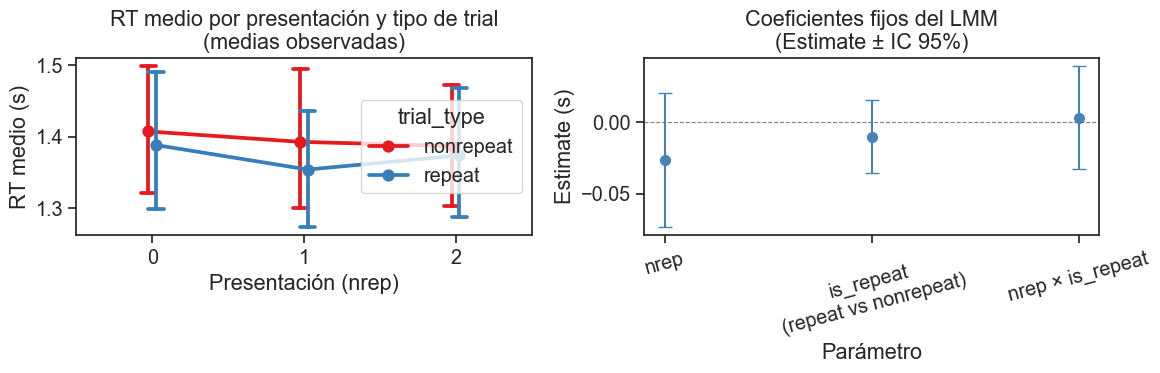


Interpretación de los efectos fijos:
  nrep          β=-0.0102 (p=0.4342)
  is_repeat     β=-0.0268 (p=0.2616)
  nrep:is_rep   β=0.0031 (p=0.8682)

  Varianza entre participantes (Group Var): 0.0482


In [7]:
# ── Panel izquierdo: medias observadas por nrep y trial_type ──────────────
avg_rt = df_rt.groupby(["subj", "nrep", "trial_type"], as_index=False)["RT"].mean()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.pointplot(
    data=avg_rt, x="nrep", y="RT", hue="trial_type",
    dodge=True, capsize=0.1, palette="Set1", ax=axes[0]
)
axes[0].set_title("RT medio por presentación y tipo de trial\n(medias observadas)")
axes[0].set_xlabel("Presentación (nrep)")
axes[0].set_ylabel("RT medio (s)")

# ── Panel derecho: coeficientes fijos del LMM con IC 95% ─────────────────
coefs_plot = coefs_rt[coefs_rt["parameter"] != "Intercept"].copy()

axes[1].axhline(0, color="gray", linestyle="--", linewidth=0.8)
axes[1].errorbar(
    x=coefs_plot["parameter"],
    y=coefs_plot["Estimate"],
    yerr=[
        coefs_plot["Estimate"] - coefs_plot["2.5_ci"],
        coefs_plot["97.5_ci"] - coefs_plot["Estimate"]
    ],
    fmt="o", color="steelblue", capsize=5, linewidth=1.5, markersize=7
)
axes[1].set_title("Coeficientes fijos del LMM\n(Estimate ± IC 95%)")
axes[1].set_xlabel("Parámetro")
axes[1].set_ylabel("Estimate (s)")
axes[1].set_xticklabels(
    ["nrep", "is_repeat\n(repeat vs nonrepeat)", "nrep × is_repeat"],
    rotation=15
)

plt.tight_layout()
plt.show()

# ── Interpretación ───────────────────────────────────────────────────────
print("\nInterpretación de los efectos fijos:")
print(f"  nrep          β={coefs_rt.loc[coefs_rt.parameter=='nrep','Estimate'].values[0]:.4f} "
      f"(p={md_rt.pvalues['nrep']:.4f})")
print(f"  is_repeat     β={coefs_rt.loc[coefs_rt.parameter=='is_repeat','Estimate'].values[0]:.4f} "
      f"(p={md_rt.pvalues['is_repeat']:.4f})")
print(f"  nrep:is_rep   β={coefs_rt.loc[coefs_rt.parameter=='nrep:is_repeat','Estimate'].values[0]:.4f} "
      f"(p={md_rt.pvalues['nrep:is_repeat']:.4f})")
print(f"\n  Varianza entre participantes (Group Var): {md_rt.cov_re.values[0][0]:.4f}")

In [8]:
# GLMM sobre precisión
# Variable respuesta binaria (0/1) → familia Binomial (equivalente a glmer en R)
# Efectos fijos: nrep × is_repeat
# Efecto aleatorio: intercepto por participante

md_correct = smf.glm(
    "correct ~ nrep * is_repeat",
    data=df_rt,
    family=sm.families.Binomial(),
    groups=df_rt["subj"]  # Nota: smf.glm no soporta efectos aleatorios directamente
).fit()

# Para variable binaria con efectos aleatorios usamos BinomialBayesMixedGLM
# que sí los soporta en statsmodels
from statsmodels.genmod.bayes_mixed_glm import BinomialBayesMixedGLM

md_correct = BinomialBayesMixedGLM.from_formula(
    "correct ~ nrep * is_repeat",
    {"subj": "0 + C(subj)"},   # intercepto aleatorio por participante
    data=df_rt
).fit_map()

print(md_correct.summary())

/opt/anaconda3/envs/SINTESI/lib/python3.10/site-packages/statsmodels/base/model.py:130: ValueWarning: unknown kwargs ['groups']
  warnings.warn(msg, ValueWarning)


                 Binomial Mixed GLM Results
               Type Post. Mean Post. SD   SD  SD (LB) SD (UB)
-------------------------------------------------------------
Intercept         M     0.9902   0.0626                      
nrep              M     0.0421   0.0487                      
is_repeat         M    -0.0805   0.0874                      
nrep:is_repeat    M    -0.0156   0.0681                      
subj              V   -25.0000   1.0000 0.000   0.000   0.000
Parameter types are mean structure (M) and variance structure
(V)
Variance parameters are modeled as log standard deviations


/opt/anaconda3/envs/SINTESI/lib/python3.10/site-packages/statsmodels/genmod/bayes_mixed_glm.py:520: UserWarning: Laplace fitting did not converge, |gradient|=9855.345016
  warnings.warn(msg)


In [11]:
# Extraemos parámetros fijos del GLMM
fe_params = md_correct.fe_mean
fe_sd     = md_correct.fe_sd

# Nombres de los parámetros fijos (los primeros 4: intercept + 3 efectos fijos)
param_names = ["Intercept", "nrep", "is_repeat", "nrep:is_repeat"]

z_vals  = fe_params / fe_sd
p_vals  = 2 * (1 - stats.norm.cdf(np.abs(z_vals)))
ci_low  = fe_params - 1.96 * fe_sd
ci_high = fe_params + 1.96 * fe_sd

coefs_correct = pd.DataFrame({
    "parameter": param_names,
    "Estimate":  fe_params,
    "SE":        fe_sd,
    "z":         z_vals,
    "p_val":     p_vals,
    "2.5_ci":    ci_low,
    "97.5_ci":   ci_high
})

print("Coeficientes fijos del GLMM sobre Precisión:")
print(coefs_correct.round(4))

Coeficientes fijos del GLMM sobre Precisión:
        parameter  Estimate      SE        z   p_val  2.5_ci  97.5_ci
0       Intercept    0.9902  0.0626  15.8293  0.0000  0.8676   1.1128
1            nrep    0.0421  0.0487   0.8651  0.3870 -0.0533   0.1376
2       is_repeat   -0.0805  0.0874  -0.9214  0.3569 -0.2519   0.0908
3  nrep:is_repeat   -0.0156  0.0681  -0.2292  0.8187 -0.1490   0.1178


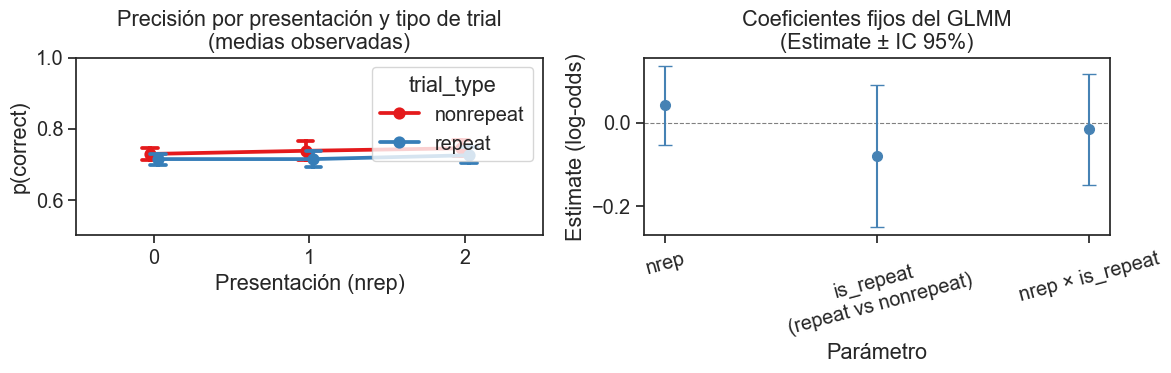


Interpretación (escala log-odds):
  nrep                 β=+0.0421  p=0.3870  → n.s.
  is_repeat            β=-0.0805  p=0.3569  → n.s.
  nrep:is_repeat       β=-0.0156  p=0.8187  → n.s.


In [13]:
avg_correct = df_rt.groupby(
    ["subj", "nrep", "trial_type"], as_index=False
)["correct"].mean()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Panel izquierdo: medias observadas
sns.pointplot(
    data=avg_correct, x="nrep", y="correct", hue="trial_type",
    dodge=True, capsize=0.1, palette="Set1", ax=axes[0]
)
axes[0].set_title("Precisión por presentación y tipo de trial\n(medias observadas)")
axes[0].set_xlabel("Presentación (nrep)")
axes[0].set_ylabel("p(correct)")
axes[0].set_ylim(0.5, 1.0)

# Panel derecho: coeficientes fijos del GLMM con IC 95%
coefs_plot = coefs_correct[coefs_correct["parameter"] != "Intercept"].copy()

axes[1].axhline(0, color="gray", linestyle="--", linewidth=0.8)
axes[1].errorbar(
    x=range(len(coefs_plot)),
    y=coefs_plot["Estimate"],
    yerr=[
        coefs_plot["Estimate"] - coefs_plot["2.5_ci"],
        coefs_plot["97.5_ci"] - coefs_plot["Estimate"]
    ],
    fmt="o", color="steelblue", capsize=5, linewidth=1.5, markersize=7
)
axes[1].set_title("Coeficientes fijos del GLMM\n(Estimate ± IC 95%)")
axes[1].set_xticks(range(len(coefs_plot)))
axes[1].set_xticklabels(
    ["nrep", "is_repeat\n(repeat vs nonrepeat)", "nrep × is_repeat"],
    rotation=15
)
axes[1].set_xlabel("Parámetro")
axes[1].set_ylabel("Estimate (log-odds)")

plt.tight_layout()
plt.show()

# Interpretación
print("\nInterpretación (escala log-odds):")
for _, row in coefs_correct[coefs_correct["parameter"] != "Intercept"].iterrows():
    sig = "✓ SIGNIFICATIVO" if row["p_val"] < 0.05 else "n.s."
    print(f"  {row['parameter']:20s} β={row['Estimate']:+.4f}  p={row['p_val']:.4f}  → {sig}")

In [14]:
# GLMM PRINCIPAL — Modelo de decisión
# Este es el modelo clave del TFG: estudia cómo la evidencia sensorial (rDV_z)
# y la decisión previa (deci1_c) interactúan con nrep y trial_type
# para predecir la decisión actual → captura el sesgo de confirmación
#
# Solo usamos nrep > 0 (presentaciones repetidas) porque en nrep=0
# no hay decisión previa que pueda generar sesgo
#
# Efectos fijos: rDV_z * deci1_c * is_repeat * nrep
# Efecto aleatorio: intercepto por participante

from statsmodels.genmod.bayes_mixed_glm import BinomialBayesMixedGLM

df_rep = df_rt[df_rt["nrep"] > 0].copy()

md_deci = BinomialBayesMixedGLM.from_formula(
    "deci ~ rDV_z * deci1_c * is_repeat * nrep",
    {"subj": "0 + C(subj)"},
    data=df_rep
).fit_map()

print(md_deci.summary())

                        Binomial Mixed GLM Results
                             Type Post. Mean Post. SD   SD  SD (LB) SD (UB)
---------------------------------------------------------------------------
Intercept                       M     0.4709   0.2162                      
rDV_z                           M     0.9985   0.2271                      
deci1_c                         M     2.5319   0.3846                      
rDV_z:deci1_c                   M     0.0088   0.4324                      
is_repeat                       M    -0.6766   0.2858                      
rDV_z:is_repeat                 M    -0.0879   0.3266                      
deci1_c:is_repeat               M     0.1574   0.5446                      
rDV_z:deci1_c:is_repeat         M    -0.4549   0.6136                      
nrep                            M    -0.1560   0.1277                      
rDV_z:nrep                      M     0.0210   0.1453                      
deci1_c:nrep                    M    

In [15]:
fe_params = md_deci.fe_mean
fe_sd     = md_deci.fe_sd

# Nombres de los efectos fijos (mismo orden que la fórmula)
param_names = [
    "Intercept",
    "rDV_z",
    "deci1_c",
    "is_repeat",
    "nrep",
    "rDV_z:deci1_c",
    "rDV_z:is_repeat",
    "deci1_c:is_repeat",
    "rDV_z:nrep",
    "deci1_c:nrep",
    "is_repeat:nrep",
    "rDV_z:deci1_c:is_repeat",
    "rDV_z:deci1_c:nrep",
    "rDV_z:is_repeat:nrep",
    "deci1_c:is_repeat:nrep",
    "rDV_z:deci1_c:is_repeat:nrep"
]

z_vals  = fe_params / fe_sd
p_vals  = 2 * (1 - stats.norm.cdf(np.abs(z_vals)))
ci_low  = fe_params - 1.96 * fe_sd
ci_high = fe_params + 1.96 * fe_sd

coefs_deci = pd.DataFrame({
    "parameter": param_names,
    "Estimate":  fe_params,
    "SE":        fe_sd,
    "z":         z_vals,
    "p_val":     p_vals,
    "2.5_ci":    ci_low,
    "97.5_ci":   ci_high
})

print("Coeficientes fijos del GLMM sobre Decisión:")
print(coefs_deci.round(4))

Coeficientes fijos del GLMM sobre Decisión:
                       parameter  Estimate      SE       z   p_val  2.5_ci  \
0                      Intercept    0.4709  0.2162  2.1785  0.0294  0.0472   
1                          rDV_z    0.9985  0.2271  4.3976  0.0000  0.5535   
2                        deci1_c    2.5319  0.3846  6.5827  0.0000  1.7780   
3                      is_repeat    0.0088  0.4324  0.0203  0.9838 -0.8387   
4                           nrep   -0.6766  0.2858 -2.3672  0.0179 -1.2368   
5                  rDV_z:deci1_c   -0.0879  0.3266 -0.2690  0.7879 -0.7279   
6                rDV_z:is_repeat    0.1574  0.5446  0.2891  0.7725 -0.9101   
7              deci1_c:is_repeat   -0.4549  0.6136 -0.7413  0.4585 -1.6575   
8                     rDV_z:nrep   -0.1560  0.1277 -1.2212  0.2220 -0.4063   
9                   deci1_c:nrep    0.0210  0.1453  0.1443  0.8853 -0.2638   
10                is_repeat:nrep    0.1279  0.2466  0.5187  0.6040 -0.3554   
11       rDV_z:deci1

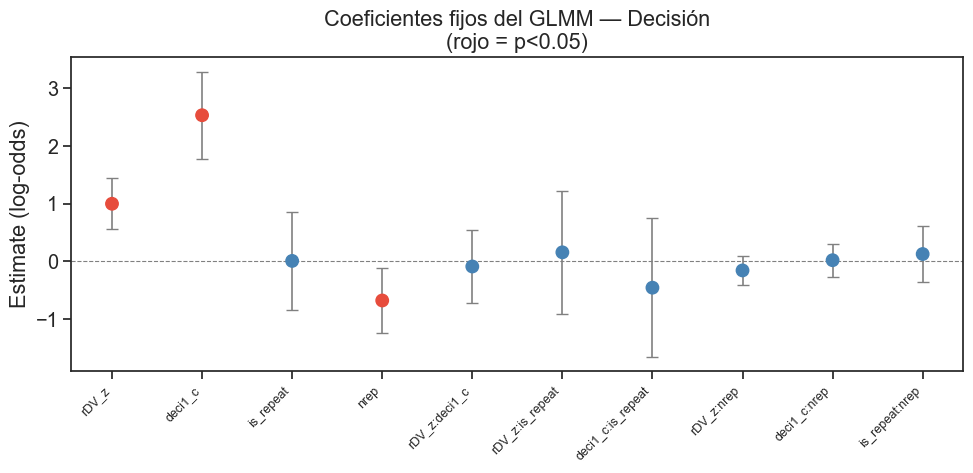


Efectos significativos (p < 0.05):
  Intercept                           β=+0.4709  p=0.0294
  rDV_z                               β=+0.9985  p=0.0000
  deci1_c                             β=+2.5319  p=0.0000
  nrep                                β=-0.6766  p=0.0179
  rDV_z:deci1_c:nrep                  β=+0.4251  p=0.0209


In [16]:
# Nos quedamos con los efectos más relevantes para el sesgo de confirmación
# (excluimos intercept e interacciones de 3er/4to orden por claridad)
params_key = ["rDV_z", "deci1_c", "is_repeat", "nrep",
              "rDV_z:deci1_c", "rDV_z:is_repeat", "deci1_c:is_repeat",
              "rDV_z:nrep", "deci1_c:nrep", "is_repeat:nrep"]

coefs_plot = coefs_deci[coefs_deci["parameter"].isin(params_key)].copy()

fig, ax = plt.subplots(figsize=(10, 5))

ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)
colors = ["#e74c3c" if p < 0.05 else "steelblue" for p in coefs_plot["p_val"]]

ax.errorbar(
    x=range(len(coefs_plot)),
    y=coefs_plot["Estimate"],
    yerr=[
        coefs_plot["Estimate"] - coefs_plot["2.5_ci"],
        coefs_plot["97.5_ci"] - coefs_plot["Estimate"]
    ],
    fmt="none", color="gray", capsize=4, linewidth=1.2, zorder=1
)
ax.scatter(
    x=range(len(coefs_plot)),
    y=coefs_plot["Estimate"],
    color=colors, s=80, zorder=2
)

ax.set_xticks(range(len(coefs_plot)))
ax.set_xticklabels(coefs_plot["parameter"], rotation=45, ha="right", fontsize=9)
ax.set_ylabel("Estimate (log-odds)")
ax.set_title("Coeficientes fijos del GLMM — Decisión\n(rojo = p<0.05)")
plt.tight_layout()
plt.show()

# Resumen de efectos significativos
print("\nEfectos significativos (p < 0.05):")
sig = coefs_deci[coefs_deci["p_val"] < 0.05]
for _, row in sig.iterrows():
    print(f"  {row['parameter']:35s} β={row['Estimate']:+.4f}  p={row['p_val']:.4f}")

In [17]:
# GLMM sobre switch (0 = repite decisión, 1 = cambia decisión)
# Solo nrep > 0 porque en nrep=0 no hay decisión previa
# Efecto aleatorio: intercepto por participante

df_rep = df_rt[df_rt["nrep"] > 0].copy()

md_switch = BinomialBayesMixedGLM.from_formula(
    "switch ~ nrep * is_repeat",
    {"subj": "0 + C(subj)"},
    data=df_rep
).fit_map()

print(md_switch.summary())

                 Binomial Mixed GLM Results
               Type Post. Mean Post. SD   SD  SD (LB) SD (UB)
-------------------------------------------------------------
Intercept         M    -1.6273   0.2097                      
nrep              M    -0.0991   0.1191                      
is_repeat         M    -0.0437   0.2696                      
nrep:is_repeat    M    -0.0905   0.1733                      
subj              V    -0.7355   0.1873 0.479   0.330   0.697
Parameter types are mean structure (M) and variance structure
(V)
Variance parameters are modeled as log standard deviations


p(cambiar decisión) basal: 0.164
p(repetir decisión) basal: 0.836



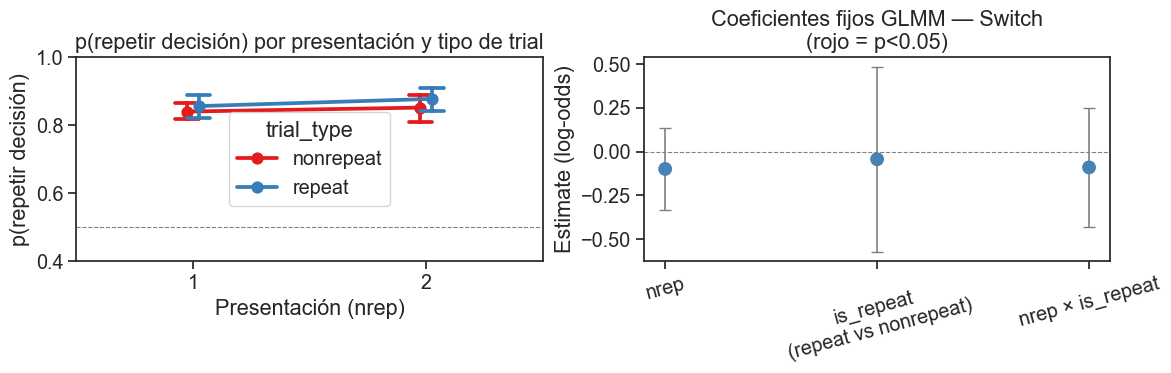


Interpretación (log-odds):
  nrep                      β=-0.0991  p=0.4051  → n.s.
  is_repeat                 β=-0.0437  p=0.8713  → n.s.
  nrep:is_repeat            β=-0.0905  p=0.6015  → n.s.


In [18]:
fe_params   = md_switch.fe_mean
fe_sd       = md_switch.fe_sd
param_names = ["Intercept", "nrep", "is_repeat", "nrep:is_repeat"]

z_vals  = fe_params / fe_sd
p_vals  = 2 * (1 - stats.norm.cdf(np.abs(z_vals)))
ci_low  = fe_params - 1.96 * fe_sd
ci_high = fe_params + 1.96 * fe_sd

coefs_switch = pd.DataFrame({
    "parameter": param_names,
    "Estimate":  fe_params,
    "SE":        fe_sd,
    "z":         z_vals,
    "p_val":     p_vals,
    "2.5_ci":    ci_low,
    "97.5_ci":   ci_high
})

# Convertir log-odds a probabilidad para el intercepto
# p(switch) = sigmoid(Intercept)
p_switch_base = 1 / (1 + np.exp(-coefs_switch.loc[0, "Estimate"]))
print(f"p(cambiar decisión) basal: {p_switch_base:.3f}")
print(f"p(repetir decisión) basal: {1 - p_switch_base:.3f}")
print()

# ── Plot ──────────────────────────────────────────────────────────────────
avg_switch = df_rep.groupby(
    ["subj", "nrep", "trial_type"], as_index=False
)["switch"].mean()
avg_switch["p_repeat"] = 1 - avg_switch["switch"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Panel izquierdo: p(repetir) observada
sns.pointplot(
    data=avg_switch, x="nrep", y="p_repeat", hue="trial_type",
    dodge=True, capsize=0.1, palette="Set1", ax=axes[0]
)
axes[0].axhline(0.5, color="gray", linestyle="--", linewidth=0.8, label="azar")
axes[0].set_title("p(repetir decisión) por presentación y tipo de trial")
axes[0].set_xlabel("Presentación (nrep)")
axes[0].set_ylabel("p(repetir decisión)")
axes[0].set_ylim(0.4, 1.0)

# Panel derecho: coeficientes GLMM
coefs_plot = coefs_switch[coefs_switch["parameter"] != "Intercept"].copy()

axes[1].axhline(0, color="gray", linestyle="--", linewidth=0.8)
colors = ["#e74c3c" if p < 0.05 else "steelblue" for p in coefs_plot["p_val"]]
axes[1].errorbar(
    x=range(len(coefs_plot)),
    y=coefs_plot["Estimate"],
    yerr=[
        coefs_plot["Estimate"] - coefs_plot["2.5_ci"],
        coefs_plot["97.5_ci"] - coefs_plot["Estimate"]
    ],
    fmt="none", color="gray", capsize=4, linewidth=1.2, zorder=1
)
axes[1].scatter(
    x=range(len(coefs_plot)),
    y=coefs_plot["Estimate"],
    color=colors, s=80, zorder=2
)
axes[1].set_xticks(range(len(coefs_plot)))
axes[1].set_xticklabels(
    ["nrep", "is_repeat\n(repeat vs nonrepeat)", "nrep × is_repeat"],
    rotation=15
)
axes[1].set_ylabel("Estimate (log-odds)")
axes[1].set_title("Coeficientes fijos GLMM — Switch\n(rojo = p<0.05)")

plt.tight_layout()
plt.show()

print("\nInterpretación (log-odds):")
for _, row in coefs_switch[coefs_switch["parameter"] != "Intercept"].iterrows():
    sig = "✓ SIGNIFICATIVO" if row["p_val"] < 0.05 else "n.s."
    print(f"  {row['parameter']:25s} β={row['Estimate']:+.4f}  p={row['p_val']:.4f}  → {sig}")

In [19]:
# GLMM METACOGNICIÓN
# Replica el análisis del tutor: md_CJnrep_metad_exp
# Modelo: correct ~ rDV_z + metad_z * deci1_c + (1|subj)
# Solo nrep > 0 (necesitamos decisión previa)
# Pregunta: ¿los participantes con mayor meta-d' se recuperan mejor
#            de decisiones previas incorrectas?

df_meta = df_rt[df_rt["nrep"] > 0].copy()
df_meta = df_meta.rename(columns={"correct-1": "correct_prev"})
df_meta["correct_prev"] = df_meta["correct_prev"].astype(float)
df_meta = df_meta.dropna(subset=["correct", "correct_prev", "metad_z"]).reset_index(drop=True)

print(f"Trials para el modelo: {len(df_meta)}")
print(f"Participantes        : {df_meta['subj'].nunique()}")

md_metad = BinomialBayesMixedGLM.from_formula(
    "correct ~ rDV_z + metad_z * correct_prev",
    {"subj": "0 + C(subj)"},
    data=df_meta
).fit_map()

print(md_metad.summary())

Trials para el modelo: 4195
Participantes        : 24
                    Binomial Mixed GLM Results
                     Type Post. Mean Post. SD   SD  SD (LB) SD (UB)
-------------------------------------------------------------------
Intercept               M    -0.9586   0.0660                      
rDV_z                   M     0.1271   0.0482                      
metad_z                 M     0.0219   0.0647                      
correct_prev            M     3.2178   0.0905                      
metad_z:correct_prev    M     0.0120   0.0901                      
subj                    V   -24.0000   1.0000 0.000   0.000   0.000
Parameter types are mean structure (M) and variance structure (V)
Variance parameters are modeled as log standard deviations


/opt/anaconda3/envs/SINTESI/lib/python3.10/site-packages/statsmodels/genmod/bayes_mixed_glm.py:520: UserWarning: Laplace fitting did not converge, |gradient|=1035.980089
  warnings.warn(msg)


In [20]:
fe_params   = md_metad.fe_mean
fe_sd       = md_metad.fe_sd
param_names = ["Intercept", "rDV_z", "metad_z", "correct_prev", "metad_z:correct_prev"]

z_vals  = fe_params / fe_sd
p_vals  = 2 * (1 - stats.norm.cdf(np.abs(z_vals)))
ci_low  = fe_params - 1.96 * fe_sd
ci_high = fe_params + 1.96 * fe_sd

coefs_metad = pd.DataFrame({
    "parameter": param_names,
    "Estimate":  fe_params,
    "SE":        fe_sd,
    "z":         z_vals,
    "p_val":     p_vals,
    "2.5_ci":    ci_low,
    "97.5_ci":   ci_high
})

print("Coeficientes fijos del GLMM — Metacognición:")
print(coefs_metad.round(4))

Coeficientes fijos del GLMM — Metacognición:
              parameter  Estimate      SE        z   p_val  2.5_ci  97.5_ci
0             Intercept   -0.9586  0.0660 -14.5143  0.0000 -1.0880  -0.8291
1                 rDV_z    0.1271  0.0482   2.6401  0.0083  0.0328   0.2215
2               metad_z    0.0219  0.0647   0.3384  0.7350 -0.1049   0.1487
3          correct_prev    3.2178  0.0905  35.5670  0.0000  3.0405   3.3952
4  metad_z:correct_prev    0.0120  0.0901   0.1333  0.8940 -0.1645   0.1886


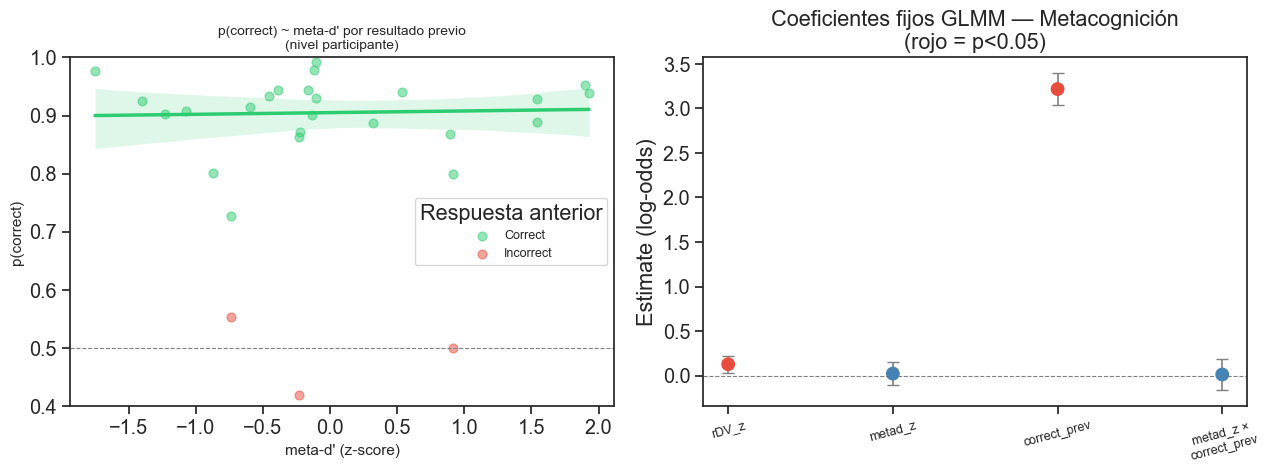


Interpretación:
  Intercept                      β=-0.9586  p=0.0000  → ✓ SIGNIFICATIVO
  rDV_z                          β=+0.1271  p=0.0083  → ✓ SIGNIFICATIVO
  metad_z                        β=+0.0219  p=0.7350  → n.s.
  correct_prev                   β=+3.2178  p=0.0000  → ✓ SIGNIFICATIVO
  metad_z:correct_prev           β=+0.0120  p=0.8940  → n.s.


In [21]:
# ── Datos observados: p(correct) por metad y correct_prev ─────────────────
df_by_subj = df_meta.groupby(
    ["subj", "correct_prev", "metad_z"], as_index=False
)["correct"].mean()
df_by_subj["correct_prev_label"] = df_by_subj["correct_prev"].map(
    {1.0: "Correct", 0.0: "Incorrect"}
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors = {"Correct": "#2ecc71", "Incorrect": "#e74c3c"}

# Panel izquierdo: regresión observada por condición previa
for prev, color in colors.items():
    d = df_by_subj[df_by_subj["correct_prev_label"] == prev]
    sns.regplot(
        data=d, x="metad_z", y="correct", color=color,
        scatter=True, ci=95, label=prev,
        scatter_kws={"alpha": 0.5, "s": 40},
        line_kws={"linewidth": 2.5}, ax=axes[0]
    )
axes[0].axhline(0.5, color="gray", linestyle="--", linewidth=0.8)
axes[0].set_xlabel("meta-d' (z-score)", fontsize=11)
axes[0].set_ylabel("p(correct)", fontsize=11)
axes[0].set_title("p(correct) ~ meta-d' por resultado previo\n(nivel participante)", fontsize=10)
axes[0].legend(title="Respuesta anterior", fontsize=9)
axes[0].set_ylim(0.4, 1.0)

# Panel derecho: coeficientes GLMM con IC 95%
coefs_plot = coefs_metad[coefs_metad["parameter"] != "Intercept"].copy()

axes[1].axhline(0, color="gray", linestyle="--", linewidth=0.8)
colors_coef = ["#e74c3c" if p < 0.05 else "steelblue" for p in coefs_plot["p_val"]]
axes[1].errorbar(
    x=range(len(coefs_plot)),
    y=coefs_plot["Estimate"],
    yerr=[
        coefs_plot["Estimate"] - coefs_plot["2.5_ci"],
        coefs_plot["97.5_ci"] - coefs_plot["Estimate"]
    ],
    fmt="none", color="gray", capsize=4, linewidth=1.2, zorder=1
)
axes[1].scatter(
    x=range(len(coefs_plot)),
    y=coefs_plot["Estimate"],
    color=colors_coef, s=80, zorder=2
)
axes[1].set_xticks(range(len(coefs_plot)))
axes[1].set_xticklabels(
    ["rDV_z", "metad_z", "correct_prev", "metad_z ×\ncorrect_prev"],
    rotation=15, fontsize=9
)
axes[1].set_ylabel("Estimate (log-odds)")
axes[1].set_title("Coeficientes fijos GLMM — Metacognición\n(rojo = p<0.05)")

plt.tight_layout()
plt.show()

print("\nInterpretación:")
for _, row in coefs_metad.iterrows():
    sig = "✓ SIGNIFICATIVO" if row["p_val"] < 0.05 else "n.s."
    print(f"  {row['parameter']:30s} β={row['Estimate']:+.4f}  p={row['p_val']:.4f}  → {sig}")

In [22]:
# GLMM CONFIANZA → SWITCH
# Pregunta: ¿mayor confianza previa reduce la probabilidad de cambiar decisión?
# Hipótesis 2: decisiones con más confianza son más estables
#
# Usamos confi-1 estandarizada como predictor del switch

df_confi = df_rt[df_rt["nrep"] > 0].copy()
df_confi = df_confi.dropna(subset=["confi-1"]).reset_index(drop=True)

# Estandarizamos confi-1 para mejorar convergencia
df_confi["confi1_z"] = (
    (df_confi["confi-1"] - df_confi["confi-1"].mean()) / df_confi["confi-1"].std()
)

print(f"Trials para el modelo: {len(df_confi)}")
print(f"Participantes        : {df_confi['subj'].nunique()}")

md_confi = BinomialBayesMixedGLM.from_formula(
    "switch ~ confi1_z * nrep * is_repeat",
    {"subj": "0 + C(subj)"},
    data=df_confi
).fit_map()

print(md_confi.summary())

Trials para el modelo: 4370
Participantes        : 25
                      Binomial Mixed GLM Results
                        Type Post. Mean Post. SD   SD  SD (LB) SD (UB)
----------------------------------------------------------------------
Intercept                  M    -2.0095   0.2588                      
confi1_z                   M    -0.9287   0.2008                      
nrep                       M     0.0484   0.1291                      
confi1_z:nrep              M     0.0449   0.1243                      
is_repeat                  M    -0.0604   0.3057                      
confi1_z:is_repeat         M    -0.1852   0.2866                      
nrep:is_repeat             M    -0.1314   0.1938                      
confi1_z:nrep:is_repeat    M    -0.0155   0.1838                      
subj                       V    -0.2450   0.1710 0.783   0.556   1.102
Parameter types are mean structure (M) and variance structure (V)
Variance parameters are modeled as log standard de

In [23]:
fe_params   = md_confi.fe_mean
fe_sd       = md_confi.fe_sd
param_names = [
    "Intercept", "confi1_z", "nrep", "is_repeat",
    "confi1_z:nrep", "confi1_z:is_repeat", "nrep:is_repeat",
    "confi1_z:nrep:is_repeat"
]

z_vals  = fe_params / fe_sd
p_vals  = 2 * (1 - stats.norm.cdf(np.abs(z_vals)))
ci_low  = fe_params - 1.96 * fe_sd
ci_high = fe_params + 1.96 * fe_sd

coefs_confi = pd.DataFrame({
    "parameter": param_names,
    "Estimate":  fe_params,
    "SE":        fe_sd,
    "z":         z_vals,
    "p_val":     p_vals,
    "2.5_ci":    ci_low,
    "97.5_ci":   ci_high
})

print("Coeficientes fijos GLMM — Confianza → Switch:")
print(coefs_confi.round(4))

Coeficientes fijos GLMM — Confianza → Switch:
                 parameter  Estimate      SE       z   p_val  2.5_ci  97.5_ci
0                Intercept   -2.0095  0.2588 -7.7634  0.0000 -2.5168  -1.5022
1                 confi1_z   -0.9287  0.2008 -4.6257  0.0000 -1.3222  -0.5352
2                     nrep    0.0484  0.1291  0.3751  0.7076 -0.2046   0.3015
3                is_repeat    0.0449  0.1243  0.3609  0.7182 -0.1988   0.2885
4            confi1_z:nrep   -0.0604  0.3057 -0.1975  0.8434 -0.6596   0.5388
5       confi1_z:is_repeat   -0.1852  0.2866 -0.6463  0.5181 -0.7469   0.3765
6           nrep:is_repeat   -0.1314  0.1938 -0.6781  0.4977 -0.5112   0.2484
7  confi1_z:nrep:is_repeat   -0.0155  0.1838 -0.0845  0.9326 -0.3758   0.3447


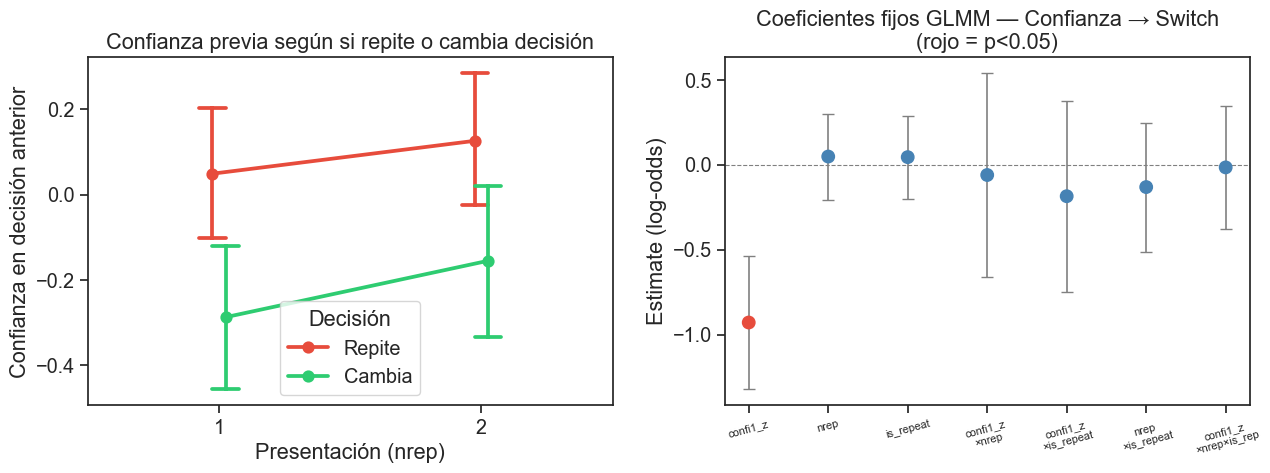


Interpretación:
  Intercept                      β=-2.0095  p=0.0000  → ✓ SIGNIFICATIVO
  confi1_z                       β=-0.9287  p=0.0000  → ✓ SIGNIFICATIVO
  nrep                           β=+0.0484  p=0.7076  → n.s.
  is_repeat                      β=+0.0449  p=0.7182  → n.s.
  confi1_z:nrep                  β=-0.0604  p=0.8434  → n.s.
  confi1_z:is_repeat             β=-0.1852  p=0.5181  → n.s.
  nrep:is_repeat                 β=-0.1314  p=0.4977  → n.s.
  confi1_z:nrep:is_repeat        β=-0.0155  p=0.9326  → n.s.


In [24]:
# ── Datos observados: switch según nivel de confianza previa ──────────────
avg_confi_switch = df_confi.groupby(
    ["subj", "nrep", "switch"], as_index=False
)["confi-1"].mean()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Panel izquierdo: confianza previa según si repite o cambia
sns.pointplot(
    data=avg_confi_switch, x="nrep", y="confi-1", hue="switch",
    dodge=True, capsize=0.1,
    palette={0: "#e74c3c", 1: "#2ecc71"}, ax=axes[0]
)
axes[0].set_title("Confianza previa según si repite o cambia decisión")
axes[0].set_xlabel("Presentación (nrep)")
axes[0].set_ylabel("Confianza en decisión anterior")
handles, labels = axes[0].get_legend_handles_labels()
axes[0].legend(handles, ["Repite", "Cambia"], title="Decisión")

# Panel derecho: coeficientes GLMM
coefs_plot = coefs_confi[coefs_confi["parameter"] != "Intercept"].copy()

axes[1].axhline(0, color="gray", linestyle="--", linewidth=0.8)
colors_c = ["#e74c3c" if p < 0.05 else "steelblue" for p in coefs_plot["p_val"]]
axes[1].errorbar(
    x=range(len(coefs_plot)),
    y=coefs_plot["Estimate"],
    yerr=[
        coefs_plot["Estimate"] - coefs_plot["2.5_ci"],
        coefs_plot["97.5_ci"] - coefs_plot["Estimate"]
    ],
    fmt="none", color="gray", capsize=4, linewidth=1.2, zorder=1
)
axes[1].scatter(
    x=range(len(coefs_plot)),
    y=coefs_plot["Estimate"],
    color=colors_c, s=80, zorder=2
)
axes[1].set_xticks(range(len(coefs_plot)))
axes[1].set_xticklabels(
    ["confi1_z", "nrep", "is_repeat",
     "confi1_z\n×nrep", "confi1_z\n×is_repeat",
     "nrep\n×is_repeat", "confi1_z\n×nrep×is_rep"],
    rotation=15, fontsize=8
)
axes[1].set_ylabel("Estimate (log-odds)")
axes[1].set_title("Coeficientes fijos GLMM — Confianza → Switch\n(rojo = p<0.05)")

plt.tight_layout()
plt.show()

print("\nInterpretación:")
for _, row in coefs_confi.iterrows():
    sig = "✓ SIGNIFICATIVO" if row["p_val"] < 0.05 else "n.s."
    print(f"  {row['parameter']:30s} β={row['Estimate']:+.4f}  p={row['p_val']:.4f}  → {sig}")

In [25]:
import warnings

# Estandarizamos cada estímulo por participante
# (mejora la convergencia y hace los betas comparables entre participantes)
for col in ["d1","d2","d3","d4","d5","d6"]:
    df_rep[f"{col}_z"] = df_rep.groupby("subj")[col].transform(
        lambda x: (x - x.mean()) / x.std()
    )

# Ajustamos un GLMM por cada nrep (1 y 2)
# Modelo: deci ~ deci1_c + d1_z + ... + d6_z + (1|subj)
# deci1_c controla el sesgo de confirmación → aísla el peso sensorial puro de cada estímulo

stim_names = ["d1_z","d2_z","d3_z","d4_z","d5_z","d6_z"]
all_names  = ["Intercept","deci1_c"] + stim_names

results_stim = []

with warnings.catch_warnings():
    warnings.simplefilter("ignore")  # suprimir warnings de convergencia menores
    for nrep_val in [1, 2]:
        dat = df_rep[df_rep["nrep"] == nrep_val].copy()
        md = BinomialBayesMixedGLM.from_formula(
            "deci ~ deci1_c + d1_z + d2_z + d3_z + d4_z + d5_z + d6_z",
            {"subj": "0 + C(subj)"},
            data=dat
        ).fit_map()

        fe, fe_sd = md.fe_mean, md.fe_sd
        z_vals = fe / fe_sd
        p_vals = 2 * (1 - stats.norm.cdf(np.abs(z_vals)))

        for i, name in enumerate(all_names):
            results_stim.append({
                "nrep":      nrep_val,
                "parameter": name,
                "Estimate":  fe[i],
                "SE":        fe_sd[i],
                "z":         z_vals[i],
                "p_val":     p_vals[i],
                "2.5_ci":    fe[i] - 1.96 * fe_sd[i],
                "97.5_ci":   fe[i] + 1.96 * fe_sd[i],
            })

df_coefs_stim = pd.DataFrame(results_stim)
print("Coeficientes estimados:")
print(df_coefs_stim.round(4))

Coeficientes estimados:
    nrep  parameter  Estimate      SE        z   p_val  2.5_ci  97.5_ci
0      1  Intercept    0.1800  0.0630   2.8580  0.0043  0.0566   0.3035
1      1    deci1_c    2.9698  0.1271  23.3604  0.0000  2.7206   3.2190
2      1       d1_z    0.4151  0.0635   6.5323  0.0000  0.2906   0.5397
3      1       d2_z    0.2881  0.0632   4.5545  0.0000  0.1641   0.4120
4      1       d3_z    0.3500  0.0637   5.4934  0.0000  0.2251   0.4749
5      1       d4_z    0.3443  0.0632   5.4442  0.0000  0.2203   0.4682
6      1       d5_z    0.3929  0.0630   6.2399  0.0000  0.2695   0.5164
7      1       d6_z    0.2867  0.0646   4.4383  0.0000  0.1601   0.4133
8      2  Intercept    0.2198  0.0656   3.3520  0.0008  0.0913   0.3483
9      2    deci1_c    3.1769  0.1308  24.2934  0.0000  2.9206   3.4332
10     2       d1_z    0.2543  0.0664   3.8281  0.0001  0.1241   0.3845
11     2       d2_z    0.3935  0.0663   5.9364  0.0000  0.2636   0.5235
12     2       d3_z    0.3742  0.0665   

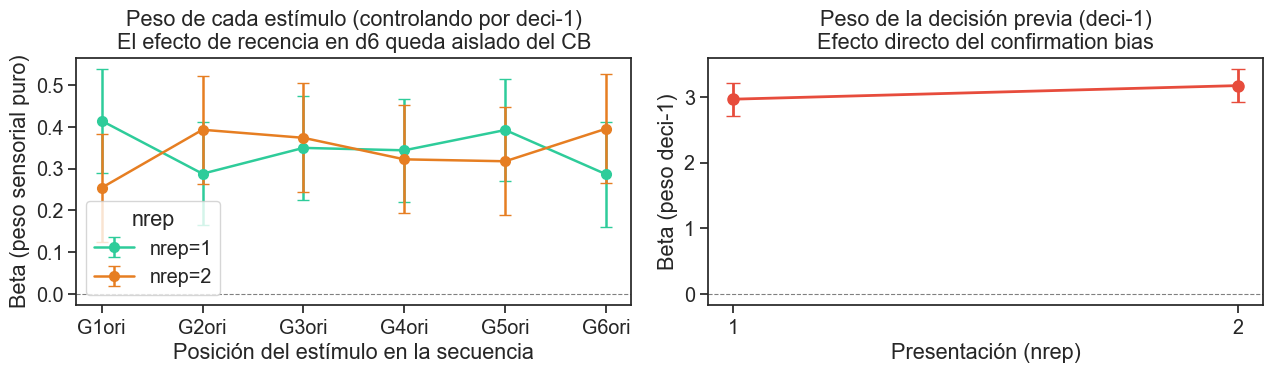

Test peso deci-1 contra 0:
  nrep=1: β=+2.9698  p=0.0000  → ✓ SIGNIFICATIVO
  nrep=2: β=+3.1769  p=0.0000  → ✓ SIGNIFICATIVO


In [26]:
df_stim = df_coefs_stim[df_coefs_stim["parameter"].isin(stim_names)].copy()
df_deci = df_coefs_stim[df_coefs_stim["parameter"] == "deci1_c"].copy()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# ── Panel izquierdo: peso sensorial puro de cada estímulo ─────────────────
palette = {1: "#2ecc9a", 2: "#e67e22"}
for nrep_val, color in palette.items():
    d = df_stim[df_stim["nrep"] == nrep_val]
    axes[0].errorbar(
        x=range(6), y=d["Estimate"],
        yerr=[d["Estimate"] - d["2.5_ci"], d["97.5_ci"] - d["Estimate"]],
        fmt="o-", color=color, capsize=4,
        label=f"nrep={nrep_val}", linewidth=1.8, markersize=7
    )
axes[0].axhline(0, color="gray", linestyle="--", linewidth=0.8)
axes[0].set_xticks(range(6))
axes[0].set_xticklabels(["G1ori","G2ori","G3ori","G4ori","G5ori","G6ori"])
axes[0].set_xlabel("Posición del estímulo en la secuencia")
axes[0].set_ylabel("Beta (peso sensorial puro)")
axes[0].set_title("Peso de cada estímulo (controlando por deci-1)\n"
                  "El efecto de recencia en d6 queda aislado del CB")
axes[0].legend(title="nrep")

# ── Panel derecho: peso de deci-1 (sesgo de confirmación directo) ─────────
axes[1].errorbar(
    x=[0, 1], y=df_deci["Estimate"],
    yerr=[df_deci["Estimate"] - df_deci["2.5_ci"],
          df_deci["97.5_ci"] - df_deci["Estimate"]],
    fmt="o-", color="#e74c3c", capsize=5, linewidth=2, markersize=8
)
axes[1].axhline(0, color="gray", linestyle="--", linewidth=0.8)
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(["1", "2"])
axes[1].set_xlabel("Presentación (nrep)")
axes[1].set_ylabel("Beta (peso deci-1)")
axes[1].set_title("Peso de la decisión previa (deci-1)\n"
                  "Efecto directo del confirmation bias")

plt.tight_layout()
plt.show()

# Significación del peso de deci-1
print("Test peso deci-1 contra 0:")
for _, row in df_deci.iterrows():
    sig = "✓ SIGNIFICATIVO" if row["p_val"] < 0.05 else "n.s."
    print(f"  nrep={row['nrep']}: β={row['Estimate']:+.4f}  p={row['p_val']:.4f}  → {sig}")

In [27]:
# GLMM STUBBORNNESS — p(no cambiar tras error)
# Stubbornness = dado que el trial anterior fue INCORRECTO,
#                ¿cuál es la probabilidad de NO cambiar de decisión?
# Un valor > 0.5 indica terquedad: el participante mantiene su decisión
# incluso cuando sabe (o debería saber) que se equivocó antes
#
# Filtramos solo los trials donde correct-1 == 0 (error previo)
# y modelamos switch ~ nrep * is_repeat

df_err = df_rep[df_rep["correct-1"] == 0].copy()

print(f"Trials con error previo : {len(df_err)}")
print(f"Stubbornness media global: {(1 - df_err['switch'].mean()):.3f}")
print()
print("Stubbornness por condición (p(no cambiar | error previo)):")
print(df_err.groupby(["nrep","trial_type"])["switch"].apply(
    lambda x: (1 - x.mean())
).round(3))

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    md_stub = BinomialBayesMixedGLM.from_formula(
        "switch ~ nrep * is_repeat",
        {"subj": "0 + C(subj)"},
        data=df_err
    ).fit_map()

print()
print(md_stub.summary())

Trials con error previo : 1208
Stubbornness media global: 0.728

Stubbornness por condición (p(no cambiar | error previo)):
nrep  trial_type
1     nonrepeat     0.687
      repeat        0.746
2     nonrepeat     0.704
      repeat        0.771
Name: switch, dtype: float64

                 Binomial Mixed GLM Results
               Type Post. Mean Post. SD   SD  SD (LB) SD (UB)
-------------------------------------------------------------
Intercept         M    -0.6950   0.2732                      
nrep              M    -0.0862   0.1751                      
is_repeat         M    -0.2404   0.3918                      
nrep:is_repeat    M    -0.0542   0.2516                      
subj              V   -25.0000   1.0000 0.000   0.000   0.000
Parameter types are mean structure (M) and variance structure
(V)
Variance parameters are modeled as log standard deviations


In [28]:
fe_params   = md_stub.fe_mean
fe_sd       = md_stub.fe_sd
param_names = ["Intercept", "nrep", "is_repeat", "nrep:is_repeat"]

z_vals  = fe_params / fe_sd
p_vals  = 2 * (1 - stats.norm.cdf(np.abs(z_vals)))
ci_low  = fe_params - 1.96 * fe_sd
ci_high = fe_params + 1.96 * fe_sd

coefs_stub = pd.DataFrame({
    "parameter": param_names,
    "Estimate":  fe_params,
    "SE":        fe_sd,
    "z":         z_vals,
    "p_val":     p_vals,
    "2.5_ci":    ci_low,
    "97.5_ci":   ci_high
})

# Convertir intercepto a probabilidad
p_stub_base = 1 / (1 + np.exp(-coefs_stub.loc[0, "Estimate"]))
print(f"p(NO cambiar | error previo) basal: {1 - p_stub_base:.3f}")
print(f"→ Los participantes mantienen su decisión errónea el "
      f"{(1 - p_stub_base)*100:.1f}% de las veces")
print()
print(coefs_stub.round(4))

p(NO cambiar | error previo) basal: 0.667
→ Los participantes mantienen su decisión errónea el 66.7% de las veces

        parameter  Estimate      SE       z   p_val  2.5_ci  97.5_ci
0       Intercept   -0.6950  0.2732 -2.5434  0.0110 -1.2306  -0.1594
1            nrep   -0.0862  0.1751 -0.4923  0.6225 -0.4293   0.2570
2       is_repeat   -0.2404  0.3918 -0.6134  0.5396 -1.0084   0.5277
3  nrep:is_repeat   -0.0542  0.2516 -0.2155  0.8294 -0.5474   0.4390


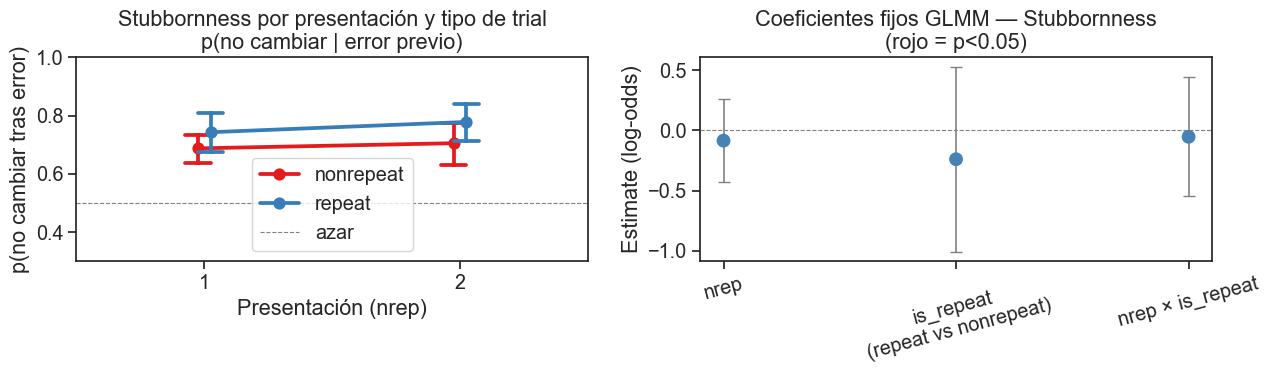


Interpretación:
  nrep                      β=-0.0862  p=0.6225  → n.s.
  is_repeat                 β=-0.2404  p=0.5396  → n.s.
  nrep:is_repeat            β=-0.0542  p=0.8294  → n.s.


In [29]:
# ── Datos observados ──────────────────────────────────────────────────────
avg_stub = df_err.groupby(
    ["subj", "nrep", "trial_type"], as_index=False
)["switch"].mean()
avg_stub["stubbornness"] = 1 - avg_stub["switch"]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Panel izquierdo: stubbornness observada por nrep y trial_type
sns.pointplot(
    data=avg_stub, x="nrep", y="stubbornness", hue="trial_type",
    dodge=True, capsize=0.1, palette="Set1", ax=axes[0]
)
axes[0].axhline(0.5, color="gray", linestyle="--", linewidth=0.8, label="azar")
axes[0].set_title("Stubbornness por presentación y tipo de trial\n"
                  "p(no cambiar | error previo)")
axes[0].set_xlabel("Presentación (nrep)")
axes[0].set_ylabel("p(no cambiar tras error)")
axes[0].set_ylim(0.3, 1.0)
axes[0].legend()

# Panel derecho: coeficientes GLMM
coefs_plot = coefs_stub[coefs_stub["parameter"] != "Intercept"].copy()

axes[1].axhline(0, color="gray", linestyle="--", linewidth=0.8)
colors_s = ["#e74c3c" if p < 0.05 else "steelblue" for p in coefs_plot["p_val"]]
axes[1].errorbar(
    x=range(len(coefs_plot)),
    y=coefs_plot["Estimate"],
    yerr=[
        coefs_plot["Estimate"] - coefs_plot["2.5_ci"],
        coefs_plot["97.5_ci"] - coefs_plot["Estimate"]
    ],
    fmt="none", color="gray", capsize=4, linewidth=1.2, zorder=1
)
axes[1].scatter(
    x=range(len(coefs_plot)),
    y=coefs_plot["Estimate"],
    color=colors_s, s=80, zorder=2
)
axes[1].set_xticks(range(len(coefs_plot)))
axes[1].set_xticklabels(
    ["nrep", "is_repeat\n(repeat vs nonrepeat)", "nrep × is_repeat"],
    rotation=15
)
axes[1].set_ylabel("Estimate (log-odds)")
axes[1].set_title("Coeficientes fijos GLMM — Stubbornness\n(rojo = p<0.05)")

plt.tight_layout()
plt.show()

print("\nInterpretación:")
for _, row in coefs_stub[coefs_stub["parameter"] != "Intercept"].iterrows():
    sig = "✓ SIGNIFICATIVO" if row["p_val"] < 0.05 else "n.s."
    print(f"  {row['parameter']:25s} β={row['Estimate']:+.4f}  p={row['p_val']:.4f}  → {sig}")

In [30]:
# ÍNDICE DE CONFIRMATION BIAS POR CONGRUENCIA
# Reordenamos los 6 estímulos según su congruencia con la decisión previa:
#   G1sim = estímulo MÁS congruente con deci-1
#   G6sim = estímulo MÁS incongruente con deci-1
#
# Si hay CB, esperamos que los estímulos congruentes (G1, G2) pesen MÁS
# que los incongruentes (G5, G6) → CB_idx = posw - negw > 0

prev_deci     = df_rep["deci-1"].copy().replace({0: -1})
orientations  = df_rep[["d1","d2","d3","d4","d5","d6"]].values
prev_respdiff = orientations * prev_deci.values[:, None]
sort_idx      = prev_respdiff.argsort(axis=1)[:, ::-1]  # descendente: más congruente primero
reo_orien     = np.take_along_axis(orientations, sort_idx, axis=1)

reo_df = pd.DataFrame(reo_orien, columns=["G1sim","G2sim","G3sim","G4sim","G5sim","G6sim"])
df_glm = pd.concat([df_rep.reset_index(drop=True), reo_df], axis=1)
df_glm["deci_prev"] = prev_deci.values

# Estandarizamos por participante
for col in ["G1sim","G2sim","G3sim","G4sim","G5sim","G6sim"]:
    df_glm[f"{col}_z"] = df_glm.groupby("subj")[col].transform(
        lambda x: (x - x.mean()) / x.std()
    )

print("Reordenación por congruencia OK")
print(df_glm[["subj","nrep","deci-1","deci_prev","G1sim","G6sim"]].head(4))

Reordenación por congruencia OK
  subj  nrep  deci-1  deci_prev     G1sim     G6sim
0  s01     1       0         -1 -0.986749  0.820733
1  s01     2       0         -1 -0.986749  0.820733
2  s01     1       1          1  0.711234 -0.734648
3  s01     2       1          1  0.711234 -0.734648


In [31]:
sim_names = ["G1sim_z","G2sim_z","G3sim_z","G4sim_z","G5sim_z","G6sim_z"]
all_names = ["Intercept","deci_prev"] + sim_names
results_sim = []

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    for nrep_val in [1, 2]:
        dat = df_glm[df_glm["nrep"] == nrep_val].copy()
        md = BinomialBayesMixedGLM.from_formula(
            "deci ~ deci_prev + G1sim_z + G2sim_z + G3sim_z + G4sim_z + G5sim_z + G6sim_z",
            {"subj": "0 + C(subj)"},
            data=dat
        ).fit_map()

        fe, fe_sd = md.fe_mean, md.fe_sd
        z_vals = fe / fe_sd
        p_vals = 2 * (1 - stats.norm.cdf(np.abs(z_vals)))

        for i, name in enumerate(all_names):
            results_sim.append({
                "nrep":      nrep_val,
                "parameter": name,
                "Estimate":  fe[i],
                "SE":        fe_sd[i],
                "z":         z_vals[i],
                "p_val":     p_vals[i],
                "2.5_ci":    fe[i] - 1.96 * fe_sd[i],
                "97.5_ci":   fe[i] + 1.96 * fe_sd[i],
            })

df_coefs_sim = pd.DataFrame(results_sim)

# ── Calcular índice CB ────────────────────────────────────────────────────
# posw = media de G1sim y G2sim (más congruentes)
# negw = media de G5sim y G6sim (más incongruentes)
# CB_idx = posw - negw → si > 0, hay sesgo de confirmación en los pesos
print("Índice CB por nrep:")
for nrep_val in [1, 2]:
    d     = df_coefs_sim[df_coefs_sim["nrep"] == nrep_val]
    posw  = d[d["parameter"].isin(["G1sim_z","G2sim_z"])]["Estimate"].mean()
    negw  = d[d["parameter"].isin(["G5sim_z","G6sim_z"])]["Estimate"].mean()
    cb    = posw - negw
    print(f"  nrep={nrep_val}: posw={posw:.4f}, negw={negw:.4f}, CB_idx={cb:.4f}")

print()
print(df_coefs_sim.round(4))

Índice CB por nrep:
  nrep=1: posw=-0.1625, negw=0.3206, CB_idx=-0.4831
  nrep=2: posw=-0.0495, negw=0.4783, CB_idx=-0.5278

    nrep  parameter  Estimate      SE        z   p_val  2.5_ci  97.5_ci
0      1  Intercept    0.0480  0.0692   0.6938  0.4878 -0.0876   0.1836
1      1  deci_prev    2.4386  0.2233  10.9187  0.0000  2.0008   2.8763
2      1    G1sim_z   -0.3252  0.2531  -1.2847  0.1989 -0.8213   0.1709
3      1    G2sim_z    0.0002  0.1993   0.0008  0.9994 -0.3905   0.3908
4      1    G3sim_z    0.4625  0.1324   3.4922  0.0005  0.2029   0.7220
5      1    G4sim_z    0.4120  0.1050   3.9250  0.0001  0.2063   0.6177
6      1    G5sim_z    0.2402  0.1400   1.7158  0.0862 -0.0342   0.5147
7      1    G6sim_z    0.4010  0.2055   1.9513  0.0510 -0.0018   0.8038
8      2  Intercept    0.0778  0.0719   1.0826  0.2790 -0.0631   0.2188
9      2  deci_prev    2.7107  0.2367  11.4501  0.0000  2.2467   3.1748
10     2    G1sim_z   -0.6322  0.2641  -2.3935  0.0167 -1.1499  -0.1145
11     2   

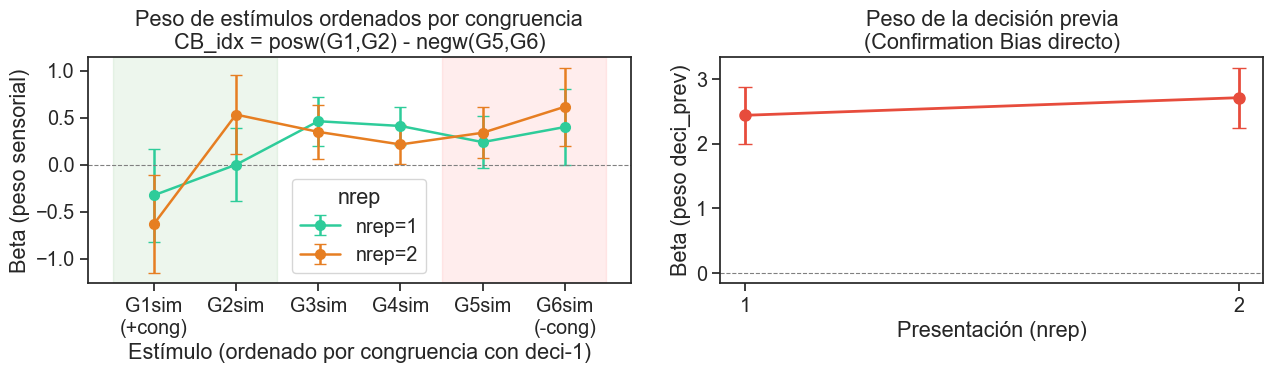

In [32]:
df_sim = df_coefs_sim[df_coefs_sim["parameter"].isin(sim_names)].copy()
df_dp  = df_coefs_sim[df_coefs_sim["parameter"] == "deci_prev"].copy()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# ── Panel izquierdo: peso de cada estímulo ordenado por congruencia ───────
palette = {1: "#2ecc9a", 2: "#e67e22"}
for nrep_val, color in palette.items():
    d = df_sim[df_sim["nrep"] == nrep_val]
    axes[0].errorbar(
        x=range(6), y=d["Estimate"],
        yerr=[d["Estimate"] - d["2.5_ci"], d["97.5_ci"] - d["Estimate"]],
        fmt="o-", color=color, capsize=4,
        label=f"nrep={nrep_val}", linewidth=1.8, markersize=7
    )
axes[0].axhline(0, color="gray", linestyle="--", linewidth=0.8)
axes[0].set_xticks(range(6))
axes[0].set_xticklabels(["G1sim\n(+cong)", "G2sim", "G3sim", "G4sim", "G5sim", "G6sim\n(-cong)"])
axes[0].set_xlabel("Estímulo (ordenado por congruencia con deci-1)")
axes[0].set_ylabel("Beta (peso sensorial)")
axes[0].set_title("Peso de estímulos ordenados por congruencia\n"
                  "CB_idx = posw(G1,G2) - negw(G5,G6)")
axes[0].legend(title="nrep")

# Añadir zonas congruente/incongruente
axes[0].axvspan(-0.5, 1.5, alpha=0.07, color="green", label="congruente")
axes[0].axvspan(3.5, 5.5, alpha=0.07, color="red",   label="incongruente")

# ── Panel derecho: peso de deci_prev ────────────────────────────────────
axes[1].errorbar(
    x=[0, 1], y=df_dp["Estimate"],
    yerr=[df_dp["Estimate"] - df_dp["2.5_ci"],
          df_dp["97.5_ci"] - df_dp["Estimate"]],
    fmt="o-", color="#e74c3c", capsize=5, linewidth=2, markersize=8
)
axes[1].axhline(0, color="gray", linestyle="--", linewidth=0.8)
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(["1", "2"])
axes[1].set_xlabel("Presentación (nrep)")
axes[1].set_ylabel("Beta (peso deci_prev)")
axes[1].set_title("Peso de la decisión previa\n(Confirmation Bias directo)")

plt.tight_layout()
plt.show()

In [35]:
# ANÁLISIS: ¿Cómo afecta la metacognición del trial anterior a la decisión siguiente?
#
# Dado que metad es una medida global (between-subjects), usamos confi-1
# como PROXY trial-a-trial de la metacognición:
# → confianza alta en t-1 = participante seguro de su decisión anterior
# → confianza baja en t-1 = participante inseguro
#
# Pregunta clave: ¿la confianza en t-1 modera el sesgo de confirmación?
# Es decir: ¿cuando estás más seguro de tu decisión anterior,
#            ¿repites más independientemente de la evidencia?

df_rep["confi-1"] = df_rep.groupby(
    ["subj", "nblock", "ntrial"]
)["confi"].shift(1)

df_meta_trial = df_rep.dropna(subset=["confi-1"]).copy()

# Estandarizamos confi-1 por participante
df_meta_trial["confi1_z"] = df_meta_trial.groupby("subj")["confi-1"].transform(
    lambda x: (x - x.mean()) / x.std()
)
df_meta_trial["correct_prev"] = df_meta_trial["correct-1"].astype(float)

print(f"Trials disponibles: {len(df_meta_trial)}")
print(f"Participantes      : {df_meta_trial['subj'].nunique()}")
print(f"\nMedia confi-1: {df_meta_trial['confi-1'].mean():.3f}")
print(f"Std   confi-1: {df_meta_trial['confi-1'].std():.3f}")

Trials disponibles: 2170
Participantes      : 25

Media confi-1: 0.089
Std   confi-1: 0.595


In [36]:
# GLMM principal:
# deci ~ rDV_z + deci1_c * confi1_z * correct_prev + (1|subj)
#
# Efectos de interés:
#   deci1_c:confi1_z         → ¿más confianza amplifica el sesgo de confirmación?
#   deci1_c:correct_prev     → ¿el sesgo cambia según si acertó o falló?
#   deci1_c:confi1_z:correct_prev → ¿la confianza modera el sesgo diferente
#                                    según si acertó o falló?

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    md_meta_trial = BinomialBayesMixedGLM.from_formula(
        "deci ~ rDV_z + deci1_c * confi1_z * correct_prev",
        {"subj": "0 + C(subj)"},
        data=df_meta_trial
    ).fit_map()

print(md_meta_trial.summary())

                         Binomial Mixed GLM Results
                              Type Post. Mean Post. SD   SD  SD (LB) SD (UB)
----------------------------------------------------------------------------
Intercept                        M     0.1756   0.1133                      
rDV_z                            M     0.7933   0.1405                      
deci1_c                          M     3.4030   0.2913                      
confi1_z                         M     0.0584   0.1130                      
deci1_c:confi1_z                 M     0.7869   0.2237                      
correct_prev                     M     0.1256   0.1516                      
deci1_c:correct_prev             M     0.1444   0.4991                      
confi1_z:correct_prev            M     0.1985   0.1502                      
deci1_c:confi1_z:correct_prev    M     0.5612   0.2966                      
subj                             V   -25.0000   1.0000 0.000   0.000   0.000
Parameter types are mean

In [37]:
fe_params   = md_meta_trial.fe_mean
fe_sd       = md_meta_trial.fe_sd
param_names = [
    "Intercept", "rDV_z", "deci1_c", "confi1_z",
    "deci1_c:confi1_z", "correct_prev",
    "deci1_c:correct_prev", "confi1_z:correct_prev",
    "deci1_c:confi1_z:correct_prev"
]

z_vals  = fe_params / fe_sd
p_vals  = 2 * (1 - stats.norm.cdf(np.abs(z_vals)))
ci_low  = fe_params - 1.96 * fe_sd
ci_high = fe_params + 1.96 * fe_sd

coefs_meta_trial = pd.DataFrame({
    "parameter": param_names,
    "Estimate":  fe_params,
    "SE":        fe_sd,
    "z":         z_vals,
    "p_val":     p_vals,
    "2.5_ci":    ci_low,
    "97.5_ci":   ci_high
})

print("Coeficientes GLMM — Metacognición trial anterior:")
print(coefs_meta_trial.round(4))
print()
print("Efectos significativos (p < 0.05):")
for _, row in coefs_meta_trial.iterrows():
    sig = "✓ SIGNIFICATIVO" if row["p_val"] < 0.05 else "n.s."
    print(f"  {row['parameter']:35s} β={row['Estimate']:+.4f}  p={row['p_val']:.4f}  → {sig}")

Coeficientes GLMM — Metacognición trial anterior:
                       parameter  Estimate      SE        z   p_val  2.5_ci  \
0                      Intercept    0.1756  0.1133   1.5502  0.1211 -0.0464   
1                          rDV_z    0.7933  0.1405   5.6477  0.0000  0.5180   
2                        deci1_c    3.4030  0.2913  11.6831  0.0000  2.8321   
3                       confi1_z    0.0584  0.1130   0.5164  0.6056 -0.1632   
4               deci1_c:confi1_z    0.7869  0.2237   3.5181  0.0004  0.3485   
5                   correct_prev    0.1256  0.1516   0.8283  0.4075 -0.1716   
6           deci1_c:correct_prev    0.1444  0.4991   0.2893  0.7723 -0.8338   
7          confi1_z:correct_prev    0.1985  0.1502   1.3211  0.1865 -0.0960   
8  deci1_c:confi1_z:correct_prev    0.5612  0.2966   1.8919  0.0585 -0.0202   

   97.5_ci  
0   0.3976  
1   1.0686  
2   3.9740  
3   0.2799  
4   1.2254  
5   0.4228  
6   1.1226  
7   0.4930  
8   1.1425  

Efectos significativos (p < 

/var/folders/6t/135j38t15hx5h_82vyspq6pm0000gn/T/ipykernel_80903/3615846391.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_meta = df_meta_trial.groupby(


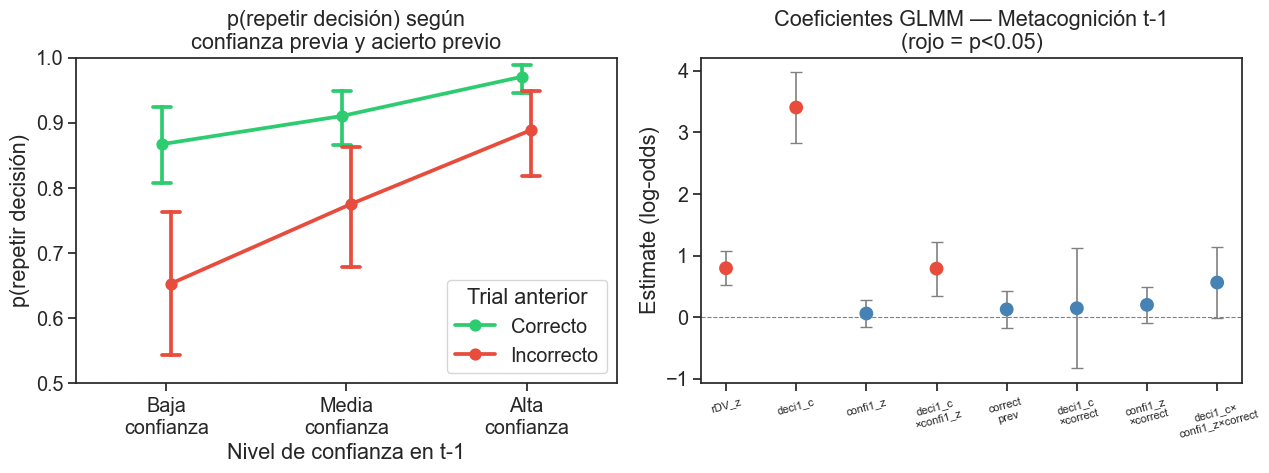

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Panel izquierdo: p(repetir) según confianza previa y correct_prev ─────
# Bineamos confi-1 en terciles para visualizar
df_meta_trial["confi1_bin"] = pd.qcut(
    df_meta_trial["confi-1"], q=3,
    labels=["Baja\nconfianza", "Media\nconfianza", "Alta\nconfianza"]
)
df_meta_trial["p_repeat"] = 1 - df_meta_trial["switch"]
df_meta_trial["prev_label"] = df_meta_trial["correct_prev"].map(
    {1.0: "Correcto", 0.0: "Incorrecto"}
)

avg_meta = df_meta_trial.groupby(
    ["subj", "confi1_bin", "prev_label"], as_index=False
)["p_repeat"].mean()

sns.pointplot(
    data=avg_meta, x="confi1_bin", y="p_repeat",
    hue="prev_label", dodge=True, capsize=0.1,
    palette={"Correcto": "#2ecc71", "Incorrecto": "#e74c3c"},
    ax=axes[0]
)
axes[0].axhline(0.5, color="gray", linestyle="--", linewidth=0.8)
axes[0].set_title("p(repetir decisión) según\nconfianza previa y acierto previo")
axes[0].set_xlabel("Nivel de confianza en t-1")
axes[0].set_ylabel("p(repetir decisión)")
axes[0].set_ylim(0.5, 1.0)
axes[0].legend(title="Trial anterior")

# ── Panel derecho: coeficientes del GLMM ─────────────────────────────────
coefs_plot = coefs_meta_trial[coefs_meta_trial["parameter"] != "Intercept"].copy()

colors_m = ["#e74c3c" if p < 0.05 else "steelblue" for p in coefs_plot["p_val"]]
axes[1].axhline(0, color="gray", linestyle="--", linewidth=0.8)
axes[1].errorbar(
    x=range(len(coefs_plot)),
    y=coefs_plot["Estimate"],
    yerr=[
        coefs_plot["Estimate"] - coefs_plot["2.5_ci"],
        coefs_plot["97.5_ci"] - coefs_plot["Estimate"]
    ],
    fmt="none", color="gray", capsize=4, linewidth=1.2, zorder=1
)
axes[1].scatter(
    x=range(len(coefs_plot)),
    y=coefs_plot["Estimate"],
    color=colors_m, s=80, zorder=2
)
axes[1].set_xticks(range(len(coefs_plot)))
axes[1].set_xticklabels(
    ["rDV_z", "deci1_c", "confi1_z",
     "deci1_c\n×confi1_z", "correct\nprev",
     "deci1_c\n×correct", "confi1_z\n×correct",
     "deci1_c×\nconfi1_z×correct"],
    rotation=15, fontsize=8
)
axes[1].set_ylabel("Estimate (log-odds)")
axes[1].set_title("Coeficientes GLMM — Metacognición t-1\n(rojo = p<0.05)")

plt.tight_layout()
plt.show()

Correct: β=-0.0740  p=0.3846
Incorrect: β=+0.0919  p=0.3501


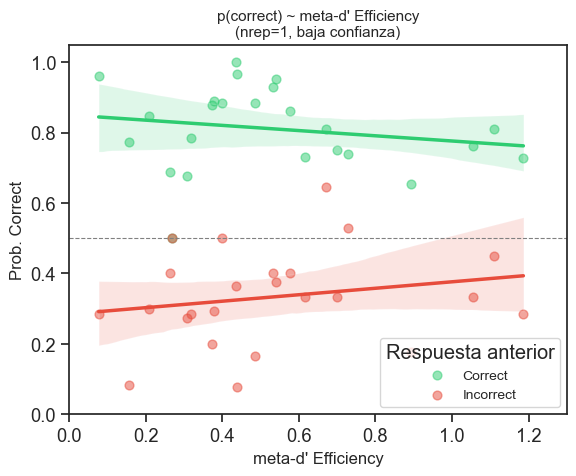

In [49]:
from scipy.stats import norm

# Calcular d' por participante (solo nrep=0, primera presentación)
df0 = df_rt[df_rt["nrep"] == 0].copy()

def calc_dprime(x):
    hits   = ((x["deci"] == 1) & (x["cond"] == 1)).sum()
    signal = (x["cond"] == 1).sum()
    fa     = ((x["deci"] == 1) & (x["cond"] == 0)).sum()
    noise  = (x["cond"] == 0).sum()
    # Corrección log-linear para evitar 0 o 1 exactos
    hr  = (hits + 0.5) / (signal + 1)
    far = (fa   + 0.5) / (noise  + 1)
    return pd.Series({"dprime": norm.ppf(hr) - norm.ppf(far)})

dprime_df  = df0.groupby("subj").apply(calc_dprime, include_groups=False).reset_index()

# metad por participante (un único valor, lo extraemos del dataset)
metad_subj = df_rt.groupby("subj")["metad"].first().reset_index()

# Merge y calcular eficiencia = metad / d'
eff_df = metad_subj.merge(dprime_df, on="subj")
eff_df["metad_eff"] = eff_df["metad"] / eff_df["dprime"]

# Solo nrep=1 (segunda presentación) y baja confianza (por debajo de la mediana)
df_p1 = df_rt[df_rt["nrep"] == 1].copy()
df_p1 = df_p1.rename(columns={"correct-1": "correct-1"})
df_p1["correct-1"] = df_p1["correct-1"].astype(float)
df_p1 = df_p1.dropna(subset=["correct", "correct-1", "metad"]).reset_index(drop=True)
df_p1 = df_p1.merge(eff_df[["subj", "metad_eff"]], on="subj")

# Filtrar baja confianza (por debajo de la mediana por participante)
median_confi  = df_p1.groupby("subj")["confi"].transform("median")
df_p1_low     = df_p1[df_p1["confi"] < median_confi].copy()

by_subj_p1 = df_p1_low.groupby(
    ["subj", "correct-1", "metad_eff"], as_index=False
)["correct"].mean()
by_subj_p1["label"] = by_subj_p1["correct-1"].map(
    {1.0: "Correct", 0.0: "Incorrect"}
)

fig, ax = plt.subplots(figsize=(6, 5))
colors = {"Correct": "#2ecc71", "Incorrect": "#e74c3c"}

for label, color in colors.items():
    d = by_subj_p1[by_subj_p1["label"] == label]
    sns.regplot(
        data=d, x="metad_eff", y="correct",
        color=color, scatter=True, ci=95, label=label,
        scatter_kws={"alpha": 0.5, "s": 40},
        line_kws={"linewidth": 2.5}, ax=ax
    )
    slope, intercept, r, p, se = stats.linregress(d["metad_eff"], d["correct"])
    print(f"{label}: β={slope:+.4f}  p={p:.4f}")

ax.axhline(0.5, color="gray", linestyle="--", linewidth=0.8)
ax.set_xlabel("meta-d' Efficiency", fontsize=12)
ax.set_ylabel("Prob. Correct", fontsize=12)
ax.set_title("p(correct) ~ meta-d' Efficiency\n(nrep=1, baja confianza)", fontsize=11)
ax.legend(title="Respuesta anterior", fontsize=10)
ax.set_ylim(0.0, 1.05)
ax.set_xlim(0.0, 1.3)
plt.tight_layout()
plt.show()